# General Examples

A place to keep processing or other functionality that may lie outside of the standard pipeline.

In [1]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import suite2p
import mbo_utilities as mbo
from copy import deepcopy
import lbm_suite2p_python as lsp
import fastplotlib as fpl
import tifffile

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),Intel(R) Graphics (RPL-P),IntegratedGPU,Vulkan,Mesa 24.0.3-1pop1~1711635559~22.04~7a9f319
❗ limited,"llvmpipe (LLVM 15.0.7, 256 bits)",CPU,Vulkan,Mesa 24.0.3-1pop1~1711635559~22.04~7a9f319 (LLVM 15.0.7)
❌,Mesa Intel(R) Graphics (RPL-P),IntegratedGPU,OpenGL,4.6 (Core Profile) Mesa 24.2.8-1~bpo12+1pop1~1744225826~22.04~b077665


## Preview Scan

### [mbo_utilities.read_scan](https://millerbrainobservatory.github.io/mbo_utilities/api/core.html#mbo_utilities.read_scan) 
reads a raw [scanimage tiff](https://millerbrainobservatory.github.io/guides/lbm_data.html#lbm-metadata) lazily.

It takes a list of filesnames ["file_1", "file_2"]:
``` python
# returns a list of 'tif' files in this directory
files = mbo.get_files("D://User_Data//animal_01//", str_contains='tif')
```

Or a [glob/wildcard](https://www.malikbrowne.com/blog/a-beginners-guide-glob-patterns/)
```python
# * matches everything after _00< including the file extensions
files = r"D://User_Data//animal_01//raw_scanimage_fname_00*"
```
And returns a `scan` object that can be used like a 4D numpy array [T, Z, X, Y]

This object takes negligible memory until it is indexed `scan[:, 0, :, :] # first z-plane`

In [2]:
# scan = mbo.read_scan(r"D://User_Data//animal_01//raw_scanimage_fname_00*)
scan = mbo.read_scan(r"/home/flynn/lbm_data/raw")
scan.shape

(1437, 14, 448, 448)

In [7]:
mbo.save_as(scan, savedir="/home/flynn/lbm_data/assembled", ext='tif', target_chunk_mb=100, subpixel_phasecorr=True)

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.


Saving plane :   0%|          | 0/84 [00:00<?, ?it/s]

Time elapsed: 0 minutes 41 seconds.


Ignore "Draw Error: Viewport has invalid rect Rect"
It is being worked on.

Data provided and set.
Is running jupyter


RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
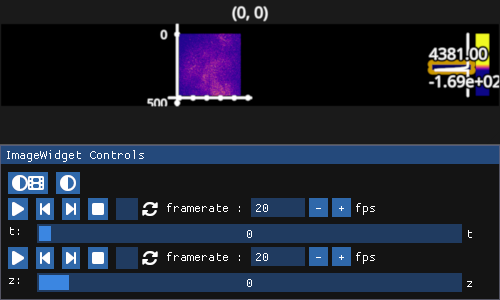

2025-05-12 09:47:39,838 [ERROR] Draw error
Traceback (most recent call last):
  File "/home/flynn/repos/work/LBM-Suite2p-Python/.venv/lib/python3.11/site-packages/rendercanvas/_coreutils.py", line 41, in log_exception
    yield
  File "/home/flynn/repos/work/LBM-Suite2p-Python/.venv/lib/python3.11/site-packages/rendercanvas/base.py", line 409, in _draw_frame_and_present
    self._draw_frame()
  File "/home/flynn/repos/work/LBM-Suite2p-Python/.venv/lib/python3.11/site-packages/fastplotlib/layouts/_imgui_figure.py", line 120, in _render
    self.imgui_renderer.render()
  File "/home/flynn/repos/work/LBM-Suite2p-Python/.venv/lib/python3.11/site-packages/wgpu/utils/imgui/imgui_renderer.py", line 168, in render
    render_pass.end()
  File "/home/flynn/repos/work/LBM-Suite2p-Python/.venv/lib/python3.11/site-packages/wgpu/backends/wgpu_native/_api.py", line 3509, in end
    libf.wgpuRenderPassEncoderEnd(self._internal)
  File "/home/flynn/repos/work/LBM-Suite2p-Python/.venv/lib/python3.11/si

In [9]:
iw = mbo.run_gui(scan)
iw.show()

In [9]:
iw.close()

In [4]:
# animal_path = Path(r"D://User_Data//animal_01//raw_scanimage_fname_00*")
assembled_path = Path(r"/home/flynn/lbm_data/assembled")
save_path = assembled_path.parent.joinpath("results")
print(f"Input path:                    {assembled_path}")
print(f"Saving suite2p results to:  {save_path}")

Input path:                    /home/flynn/lbm_data/assembled
Saving suite2p results to:  /home/flynn/lbm_data/results


In [5]:
input_file = mbo.get_files(assembled_path, '8')[0] # list -> string
input_file

'/home/flynn/lbm_data/assembled/plane_08.tif'

In [6]:
ops = lsp.run_plane(
    input_path = input_file,
    save_path = save_path,
    debug=True,
    keep_raw=True
)

ic| f'Loading ops from existing file: {ops_path}': 'Loading ops from existing file: /home/flynn/lbm_data/results/plane8/ops.npy'


Applying user ops: {}


KeyError: 'run_plane_bin: missing frame count (nframes or n_frames)'

## Preview registration

In [13]:
ops["reg_file"]

'/home/flynn/lbm_data/results/plane8/data_raw.bin'

In [6]:
reg_file = ops
reg = np.concatenate(
    [imread(tif) for tif in files]
)

NameError: name 'files' is not defined

## Plots are generated automatically in the save_path. You can also create them manually.

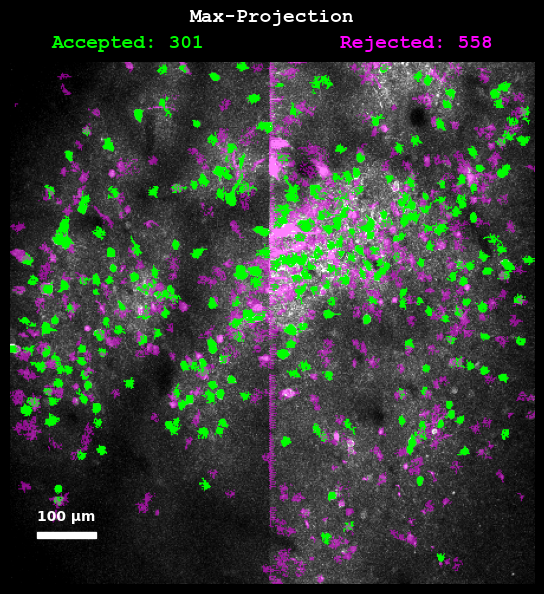

In [29]:
# ops_plane_7 = lsp.load_ops("/home/flynn/results/plane7/ops.npy")  # use this if you don't have ops in memory
lsp.plot_projection(ops, add_scalebar=True, proj="max_proj", display_masks=True, accepted_only=False)

In [27]:
# you can do this too
#iw = fpl.ImageWidget(data=scan)

In [12]:
scan.shape

(1437, 14, 448, 448)

In [3]:
zstack = scan[50, :, :, :]
data.shape

(14, 448, 448)

In [26]:
# very easy filesystem traversal: Path(string).parent.parent.joinpath("path", "to", "file")
ops_files = mbo.get_files(Path(assembled_path).parent.joinpath("results"), "ops.npy", 4)
print([Path(x).parts[-3:] for x in ops_files[:3]])  # sorry this is ugly, to hide the root directory for the notebook output

[('plane_01_mk301', 'plane0', 'ops.npy'), ('plane_02_mk301', 'plane0', 'ops.npy'), ('plane_03_mk301', 'plane0', 'ops.npy')]


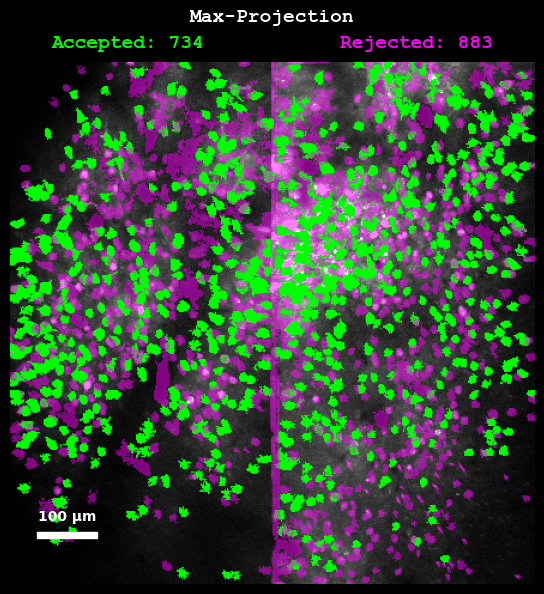

In [31]:
ops_plane_7 = lbm_suite2p_python.zplane.load_ops(ops_files[7])
lsp.plot_projection(ops_plane_7, add_scalebar=True, proj="max_proj", display_masks=True, accepted_only=False)

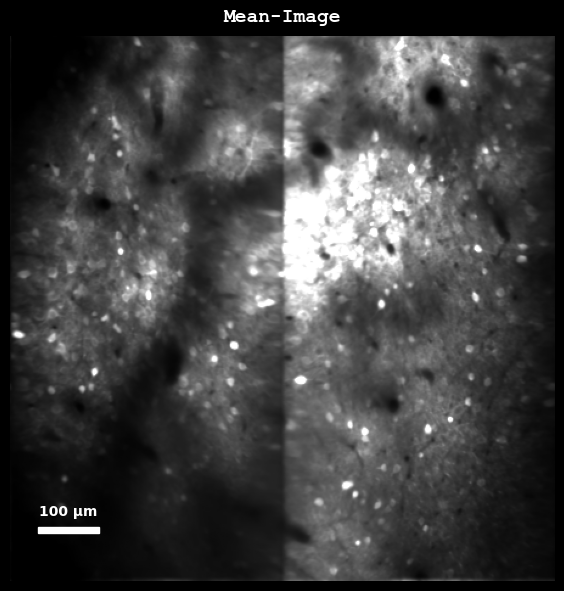

In [33]:
lsp.plot_projection(ops_plane_7, add_scalebar=True, proj="meanImg", display_masks=False)

In [ ]:
f, fneu, spks = lsp.load_traces(ops_plane_7)
spks = lbm_suite2p_python.zplane.load_planar_results(ops_plane_7)
# lsp.plot_rastermap(

## Compare multiple z-planes

In [6]:
plane_6 = tifffile.memmap(input_files[5])
plane_7 = tifffile.memmap(input_files[6])

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
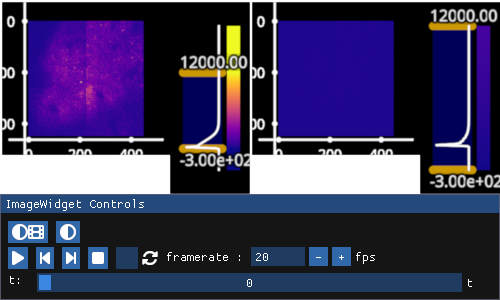

Draw error
Traceback (most recent call last):
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\rendercanvas\_coreutils.py", line 41, in log_exception
    yield
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\rendercanvas\base.py", line 409, in _draw_frame_and_present
    self._draw_frame()
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\fastplotlib\layouts\_imgui_figure.py", line 111, in _render
    self.imgui_renderer.render()
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\wgpu\utils\imgui\imgui_renderer.py", line 161, in render
    render_pass.end()
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\wgpu\backends\wgpu_native\_api.py", line 3289, in end
    libf.wgpuRenderPassEncoderEnd(self._internal)
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\wgpu\backends\wgpu_native\_helpers.py", line 394, in proxy_func
    raise wgpu_error  # the frame above is more interesting ↑↑
wgpu._classes.GPUValidationError: Validation Erro

In [10]:
iw = fpl.ImageWidget(data=[plane_6, plane_7])
iw.show()